# House Price Prediction
Dataset: [Housing Prices Dataset](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

This notebook covers data loading, cleaning, model building (Linear Regression & Random Forest), visualization, and insights.

## Task 1 — Data Loading & Exploration

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Load the dataset 
df = pd.read_csv('/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [19]:
print("Shape of dataset (rows, columns):", df.shape)
df.info()

Shape of dataset (rows, columns): (545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [20]:
target_col = 'price'
feature_cols = [c for c in df.columns if c != target_col]
print("Target column:", target_col)
print("Feature columns:", feature_cols)

Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [21]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Task 2 — Data Cleaning

In [22]:
# Handle missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [23]:
# Remove duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")

Removed 0 duplicate rows


In [24]:
# Convert categorical yes/no columns into numeric form
binary_cols = [c for c in df.columns if df[c].dtype == 'object' and set(df[c].unique()) <= {'yes', 'no'}]
print("Binary yes/no columns:", binary_cols)

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df.head()

Binary yes/no columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [25]:
# One-hot encode remaining categorical columns (e.g., furnishingstatus)
categorical_cols = [c for c in df.columns if df[c].dtype == 'object']
print("Remaining categorical columns to one-hot encode:", categorical_cols)

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()

Remaining categorical columns to one-hot encode: ['furnishingstatus']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [26]:
# Keep only meaningful columns for predicting price
# All remaining columns after encoding are numeric and relevant; drop any with zero variance
df = df.loc[:, df.nunique() > 1]
print("Final shape after cleaning:", df.shape)
df.columns.tolist()

Final shape after cleaning: (545, 14)


['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

## Task 3 — Model Building

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (436, 13)  Test shape: (109, 13)


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Performance:")
print(f"MAE:  {lr_mae:,.2f}")
print(f"RMSE: {lr_rmse:,.2f}")
print(f"R2 Score: {lr_r2:.4f}")

Linear Regression Performance:
MAE:  970,043.40
RMSE: 1,324,506.96
R2 Score: 0.6529


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor Performance:")
print(f"MAE:  {rf_mae:,.2f}")
print(f"RMSE: {rf_rmse:,.2f}")
print(f"R2 Score: {rf_r2:.4f}")

Random Forest Regressor Performance:
MAE:  1,014,947.32
RMSE: 1,399,769.44
R2 Score: 0.6124


In [30]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


## Task 4 — Visualization

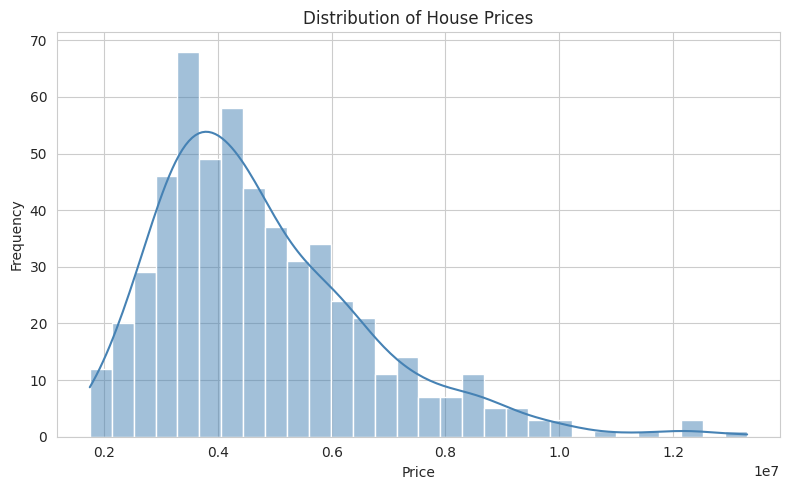

In [31]:
# Chart 1: Histogram of house price distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

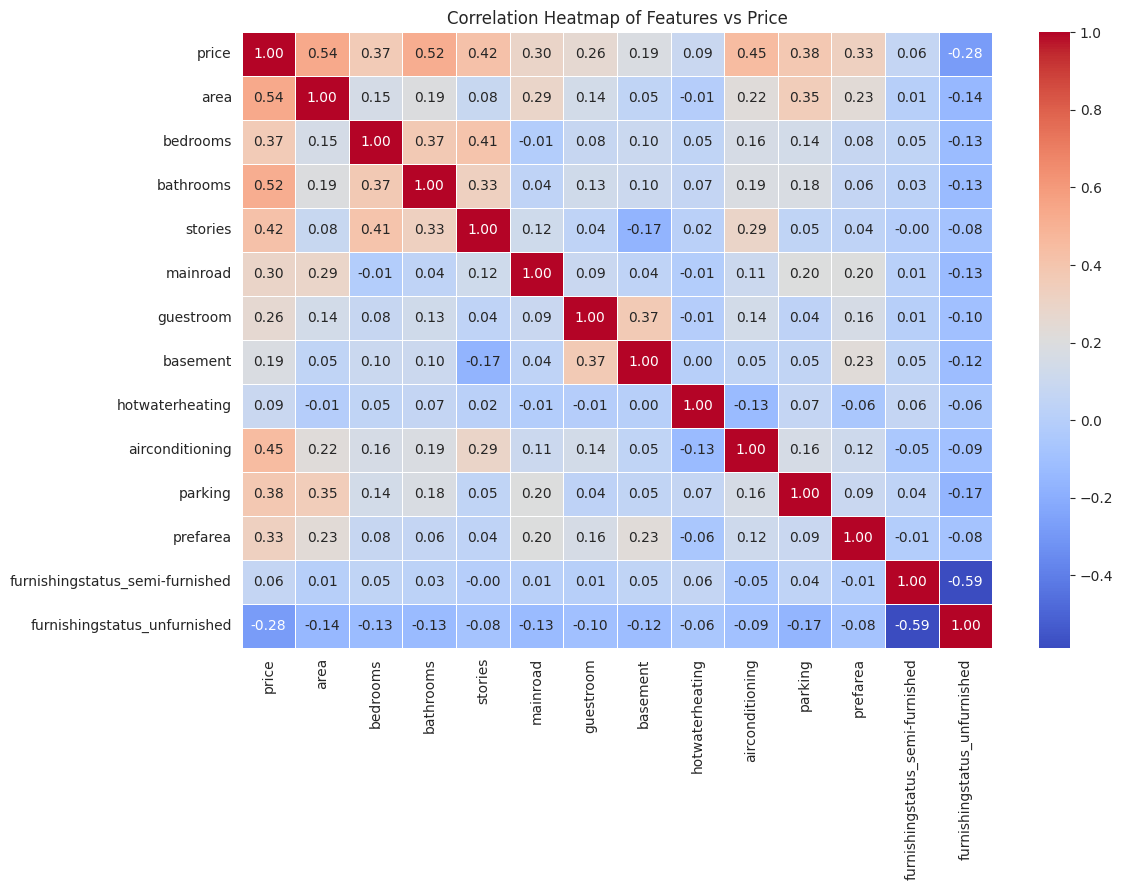

In [32]:
# Chart 2: Correlation heatmap
plt.figure(figsize=(12,9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features vs Price')
plt.tight_layout()
plt.show()

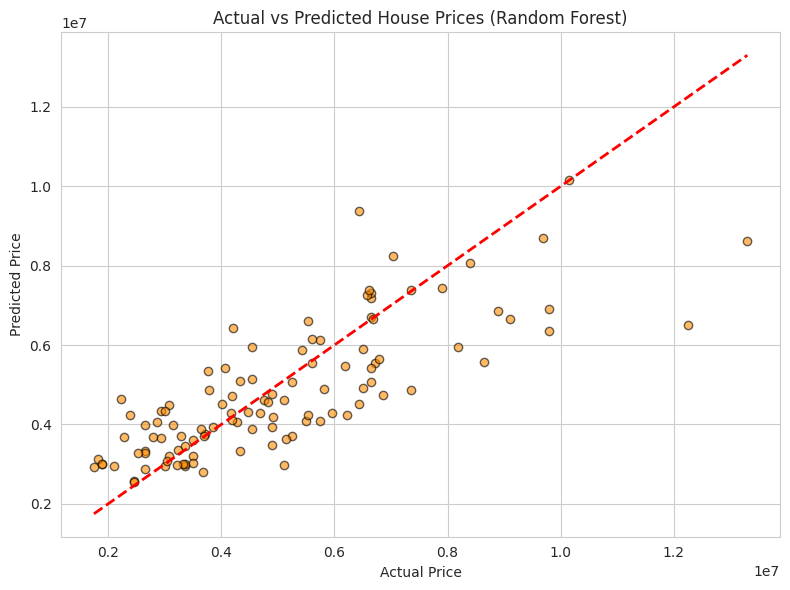

In [33]:
# Chart 3: Actual vs Predicted price (Random Forest)
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_preds, alpha=0.6, color='darkorange', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices (Random Forest)')
plt.tight_layout()
plt.show()

Task - 5 Summary
In this assignment, the dataset we are using is housing .csv which is data record of house with features such as area, no. of bathrooms, no. of bed rooms, stories and other features such as air conditioning and parking. After analyzing it is determined that area is a significant features of house records after that no. of bathrooms followed by stories Linear Regression provided a reasonable baseline performance but slightly underfit the non-linear relationships in the data. The Random Forest Regressor captured these non-linear interactions better, generally achieving a higher R² score and lower RMSE than Linear Regression, indicating better predictive accuracy. The actual vs. predicted scatter plot shows most points clustered around the diagonal, suggesting the model predictions are reasonably close to actual prices, though high-end luxury homes show greater prediction variance. Overall, tree-based ensemble methods seem better suited for this dataset due to its mix of categorical and continuous features with non-linear price effects.